In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

## 1.Data Collection 

In [3]:
now = datetime.now()

start = datetime(now.year-10, now.month, now.day)
end = now
ticker = 'AAPL'
df = yf.download(ticker, start, end)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-07-06,21.747374,21.776969,21.483301,21.535659,123796400
2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400
2016-07-08,22.009163,22.056969,21.865744,21.965909,115648400
2016-07-11,22.077465,22.229990,22.020553,22.025105,95179600
2016-07-12,22.177628,22.241369,22.109334,22.120715,96670000
...,...,...,...,...,...
2026-06-26,283.779999,285.950012,274.209991,275.000000,261775500
2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000


In [4]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-07-06,21.747374,21.776969,21.483301,21.535659,123796400
2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400
2016-07-08,22.009163,22.056969,21.865744,21.965909,115648400
2016-07-11,22.077465,22.229990,22.020553,22.025105,95179600
2016-07-12,22.177628,22.241369,22.109334,22.120715,96670000


In [5]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-06-26,283.779999,285.950012,274.209991,275.000000,261775500
2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000
2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200
2026-07-01,294.380005,296.589996,289.200012,293.440002,50164200
2026-07-02,308.630005,309.420013,293.679993,294.119995,75352800


## 2.Data Exploration & Visualization

In [6]:
type(df)

pandas.DataFrame

In [7]:
df.shape

(2512, 5)

In [8]:
df.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [9]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2512.000000,2512.000000,2512.000000,2512.000000,2.512000e+03
mean,126.640287,127.915280,125.254500,126.526029,9.572879e+07
std,77.885958,78.665928,77.061525,77.821714,5.466117e+07
min,21.747374,21.776969,21.483301,21.535659,1.791060e+07
25%,45.602929,46.026893,45.244688,45.630970,5.656430e+07
50%,131.173088,132.603845,129.812034,131.521145,8.388080e+07
75%,182.581417,184.371777,180.725067,182.300893,1.156325e+08
max,315.200012,317.399994,309.649994,314.179993,4.479400e+08


In [10]:
df.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [11]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-07-06,21.747374,21.776969,21.483301,21.535659,123796400
2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400
2016-07-08,22.009163,22.056969,21.865744,21.965909,115648400
2016-07-11,22.077465,22.229990,22.020553,22.025105,95179600
2016-07-12,22.177628,22.241369,22.109334,22.120715,96670000


In [12]:
df = df.reset_index()

In [13]:
df

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-07-06,21.747374,21.776969,21.483301,21.535659,123796400
1,2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400
2,2016-07-08,22.009163,22.056969,21.865744,21.965909,115648400
3,2016-07-11,22.077465,22.229990,22.020553,22.025105,95179600
4,2016-07-12,22.177628,22.241369,22.109334,22.120715,96670000
...,...,...,...,...,...,...
2507,2026-06-26,283.779999,285.950012,274.209991,275.000000,261775500
2508,2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000
2509,2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200


Text(0, 0.5, 'Close price')

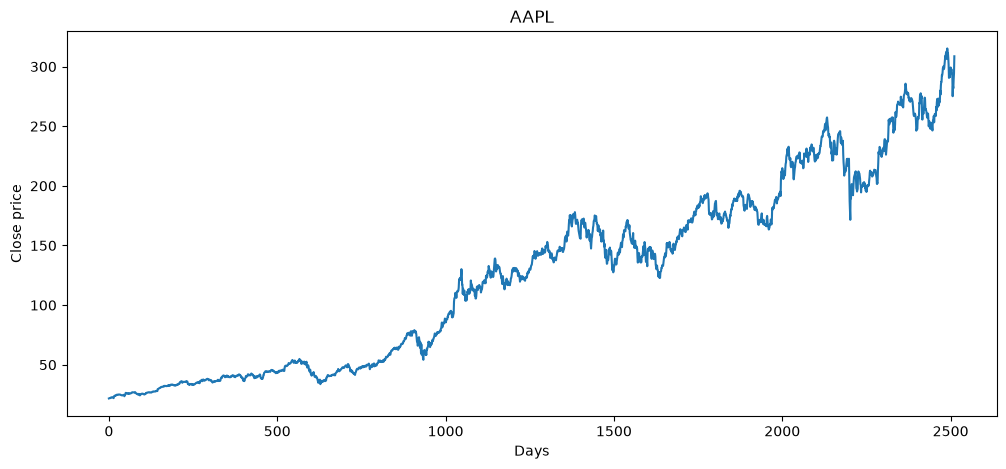

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close price')

## 3.Feature Engineering

In [15]:
temp_df = [10,20,30,40,50,60,70,80,90,100]
print(sum(temp_df[2:7])/5)

50.0


In [16]:
df1 = pd.DataFrame([10,20,30,40,50,60,70,80,90,100])
df1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [17]:
df1['MA_5'] = df1.rolling(5).mean()
df1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


### 100 days of Moving Average

In [18]:
df['MA_100'] = df.Close.rolling(100).mean()
df.head()

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-07-06,21.747374,21.776969,21.483301,21.535659,123796400,NaN
1,2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400,NaN
2,2016-07-08,22.009163,22.056969,21.865744,21.965909,115648400,NaN
3,2016-07-11,22.077465,22.229990,22.020553,22.025105,95179600,NaN
4,2016-07-12,22.177628,22.241369,22.109334,22.120715,96670000,NaN


In [19]:
df.head(103)

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-07-06,21.747374,21.776969,21.483301,21.535659,123796400,NaN
1,2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400,NaN
2,2016-07-08,22.009163,22.056969,21.865744,21.965909,115648400,NaN
3,2016-07-11,22.077465,22.229990,22.020553,22.025105,95179600,NaN
4,2016-07-12,22.177628,22.241369,22.109334,22.120715,96670000,NaN
...,...,...,...,...,...,...,...
98,2016-11-22,25.720486,25.863121,25.628462,25.754993,103862000,NaN
99,2016-11-23,25.589346,25.653762,25.382293,25.619253,109705600,24.901194
100,2016-11-25,25.718180,25.736585,25.524930,25.566341,45903600,24.940902


Text(0, 0.5, 'Price')

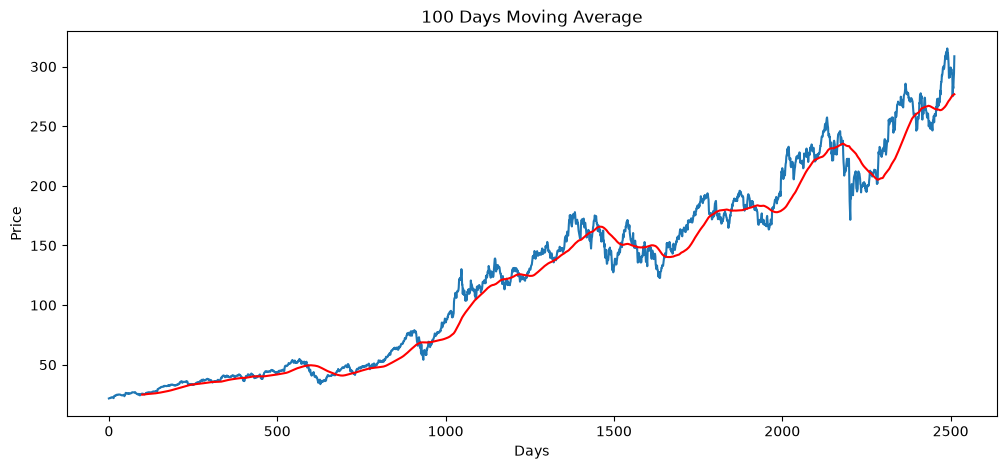

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.plot(df["MA_100"], 'r')
plt.title("100 Days Moving Average")
plt.xlabel('Days')
plt.ylabel('Price')

### 100 days of Moving Average

In [21]:
df['MA_200'] = df.Close.rolling(200).mean()
df.head()

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-07-06,21.747374,21.776969,21.483301,21.535659,123796400,NaN,NaN
1,2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400,NaN,NaN
2,2016-07-08,22.009163,22.056969,21.865744,21.965909,115648400,NaN,NaN
3,2016-07-11,22.077465,22.229990,22.020553,22.025105,95179600,NaN,NaN
4,2016-07-12,22.177628,22.241369,22.109334,22.120715,96670000,NaN,NaN


In [22]:
df.head(203)

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-07-06,21.747374,21.776969,21.483301,21.535659,123796400,NaN,NaN
1,2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400,NaN,NaN
2,2016-07-08,22.009163,22.056969,21.865744,21.965909,115648400,NaN,NaN
3,2016-07-11,22.077465,22.229990,22.020553,22.025105,95179600,NaN,NaN
4,2016-07-12,22.177628,22.241369,22.109334,22.120715,96670000,NaN,NaN
...,...,...,...,...,...,...,...,...
198,2017-04-19,32.504871,32.809866,32.451730,32.782141,69313600,29.594021,NaN
199,2017-04-20,32.911533,33.022439,32.615783,32.629645,93278400,29.667243,27.284218
200,2017-04-21,32.872269,32.966999,32.775226,32.911548,69283600,29.738784,27.339843


Text(0, 0.5, 'Price')

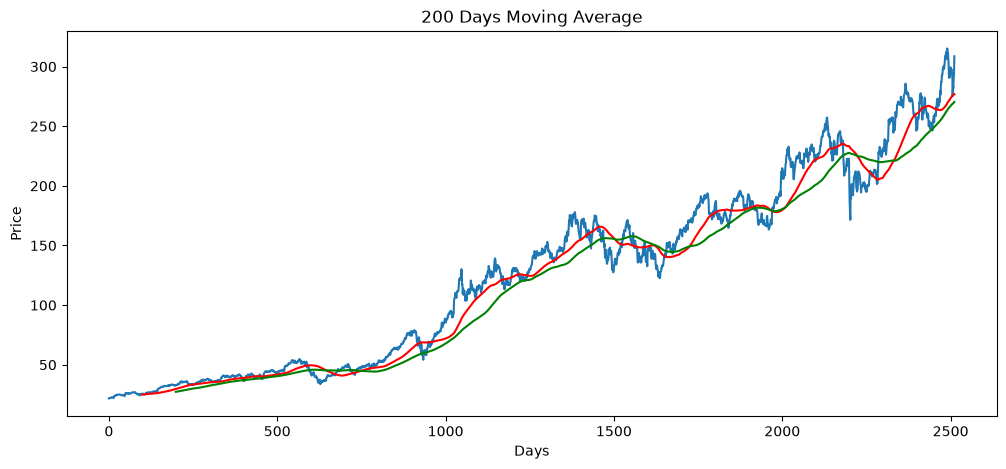

In [23]:
 plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.plot(df["MA_100"], 'r')
plt.plot(df["MA_200"], 'g')
plt.title("200 Days Moving Average")
plt.xlabel('Days')
plt.ylabel('Price')

In [24]:
df

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-07-06,21.747374,21.776969,21.483301,21.535659,123796400,NaN,NaN
1,2016-07-07,21.840704,21.968187,21.767856,21.786067,100558400,NaN,NaN
2,2016-07-08,22.009163,22.056969,21.865744,21.965909,115648400,NaN,NaN
3,2016-07-11,22.077465,22.229990,22.020553,22.025105,95179600,NaN,NaN
4,2016-07-12,22.177628,22.241369,22.109334,22.120715,96670000,NaN,NaN
...,...,...,...,...,...,...,...,...
2507,2026-06-26,283.779999,285.950012,274.209991,275.000000,261775500,275.981114,269.075539
2508,2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000,276.108711,269.353488
2509,2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200,276.242539,269.653382


### Calculating % changed in each trading session

In [25]:
df["Percentage changed"] = df.Close.pct_change()


In [26]:
df[['Close', 'Percentage changed']]

Price,Close,Percentage changed
Ticker,AAPL,
0,21.747374,NaN
1,21.840704,0.004292
2,22.009163,0.007713
3,22.077465,0.003103
4,22.177628,0.004537
...,...,...
2507,283.779999,0.031365
2508,281.739990,-0.007189
2509,289.359985,0.027046


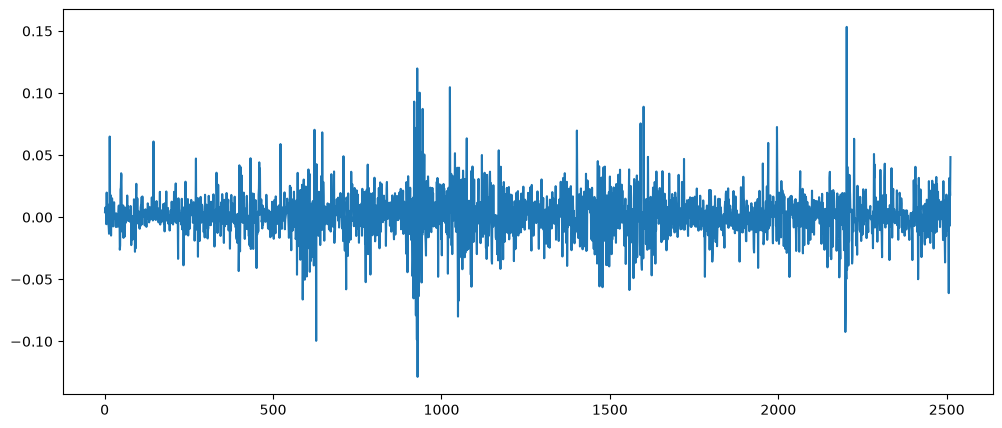

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(df['Percentage changed'])

## 4.Data Preprocessing

In [28]:
df.shape

(2512, 9)

In [29]:
# Splitting data into Training and Testing datasets
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7): int(len(df))])

print(data_training)
print(data_testing)

Ticker        AAPL
0        21.747374
1        21.840704
2        22.009163
3        22.077465
4        22.177628
...            ...
1753    184.099075
1754    182.708572
1755    185.459991
1756    186.633545
1757    186.968857

[1758 rows x 1 columns]
Ticker        AAPL
1758    191.288300
1759    189.799179
1760    188.684784
1761    189.158173
1762    188.043762
...            ...
2507    283.779999
2508    281.739990
2509    289.359985
2510    294.380005
2511    308.630005

[754 rows x 1 columns]


In [30]:
# Scaling down the data between 0 and 1

In [31]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [32]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.00000000e+00],
       [5.64880435e-04],
       [1.58447507e-03],
       ...,
       [9.90867620e-01],
       [9.97970531e-01],
       [1.00000000e+00]], shape=(1758, 1))

In [33]:
type(data_training_array)

numpy.ndarray

In [34]:
data_training_array.shape

(1758, 1)

## 5.Sequence Creation

In [35]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i,0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [36]:
x_train

array([[[0.00000000e+00],
        [5.64880435e-04],
        [1.58447507e-03],
        ...,
        [2.39497206e-02],
        [2.40471882e-02],
        [2.32534673e-02]],

       [[5.64880435e-04],
        [1.58447507e-03],
        [1.99787261e-03],
        ...,
        [2.40471882e-02],
        [2.32534673e-02],
        [2.40332313e-02]],

       [[1.58447507e-03],
        [1.99787261e-03],
        [2.60410435e-03],
        ...,
        [2.32534673e-02],
        [2.40332313e-02],
        [2.37269639e-02]],

       ...,

       [[7.33897032e-01],
        [7.65975480e-01],
        [7.87876938e-01],
        ...,
        [9.84540756e-01],
        [9.82630700e-01],
        [9.74214707e-01]],

       [[7.65975480e-01],
        [7.87876938e-01],
        [7.71391369e-01],
        ...,
        [9.82630700e-01],
        [9.74214707e-01],
        [9.90867620e-01]],

       [[7.87876938e-01],
        [7.71391369e-01],
        [7.88769812e-01],
        ...,
        [9.74214707e-01],
        [9.9086

In [37]:
y_train

array([0.02403323, 0.02372696, 0.02357376, ..., 0.99086762, 0.99797053,
       1.        ], shape=(1658,))

In [38]:
y_train.ndim

1

In [39]:
x_train.shape

(1658, 100, 1)

In [40]:
y_train.shape

(1658,)

## 6.Model Building

In [41]:
!pip install tensorflow

  Using cached keras-3.15.0-py3-none-any.whl.metadata (6.3 kB)
Using cached keras-3.15.0-py3-none-any.whl (1.7 MB)
  Attempting uninstall: keras
    Found existing installation: keras 2.6.0
    Uninstalling keras-2.6.0:
      Successfully uninstalled keras-2.6.0


In [42]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [43]:
# ML Model
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input


In [44]:
model = Sequential()

model.add(Input(shape= (100, 1)))
model.add(LSTM(units=128, activation = 'tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(1))

## 7.Model Training

In [45]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 0.0113
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 7.3194e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 6.8920e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 6.9034e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 6.5597e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 5.6849e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 5.9548e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 5.5165e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 5.5598e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 5.0196e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 5.0661e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 4.6151e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 4.7135e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 3.9625e-04
Epoch 15/50
52/52 ━

In [46]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 348,101 (1.33 MB)

 Trainable params: 116,033 (453.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 232,068 (906.52 KB)

In [47]:
import tensorflow as tf
print(tf.__version__)


2.21.0


In [48]:
import keras
print(keras.__version__)

3.15.0


In [49]:
!pip install h5py

In [54]:
#model.save('stock_prediction_model.keras')

## 8.Preparing Test Data

In [56]:
data_training.tail(100)

Ticker,AAPL
1658,149.197800
1659,152.069092
1660,149.384598
1661,148.352127
1662,148.716537
...,...
1753,184.099075
1754,182.708572
1755,185.459991
1756,186.633545


In [57]:
data_testing

Ticker,AAPL
1758,191.288300
1759,189.799179
1760,188.684784
1761,189.158173
1762,188.043762
...,...
2507,283.779999
2508,281.739990
2509,289.359985
2510,294.380005


In [59]:
past_100_days = data_training.tail(100)

In [60]:
past_100_days

Ticker,AAPL
1658,149.197800
1659,152.069092
1660,149.384598
1661,148.352127
1662,148.716537
...,...
1753,184.099075
1754,182.708572
1755,185.459991
1756,186.633545


In [62]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)
final_df

Ticker,AAPL
0,149.197800
1,152.069092
2,149.384598
3,148.352127
4,148.716537
...,...
849,283.779999
850,281.739990
851,289.359985
852,294.380005


In [64]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.03541433],
       [0.05209848],
       [0.03649975],
       [0.03050039],
       [0.03261787],
       [0.04886952],
       [0.04514989],
       [0.05733861],
       [0.04806844],
       [0.04143044],
       [0.01814011],
       [0.0206008 ],
       [0.02340471],
       [0.00801123],
       [0.01493553],
       [0.01201698],
       [0.        ],
       [0.00343333],
       [0.03273233],
       [0.04875523],
       [0.0359941 ],
       [0.04326153],
       [0.03021428],
       [0.01825457],
       [0.02952775],
       [0.04165928],
       [0.04394832],
       [0.06031444],
       [0.05545034],
       [0.0691842 ],
       [0.07994242],
       [0.0716448 ],
       [0.07793941],
       [0.08549287],
       [0.07421978],
       [0.07061462],
       [0.08846887],
       [0.09756757],
       [0.11210233],
       [0.11936994],
       [0.11627982],
       [0.10557871],
       [0.11072884],
       [0.09567894],
       [0.08864035],
       [0.08463478],
       [0.11587897],
       [0.113

In [65]:
input_data.shape

(854, 1)

In [67]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i,0])

In [68]:
x_test, y_test = np.array(x_test), np.array(y_test)

In [69]:
x_test

array([[[0.03541433],
        [0.05209848],
        [0.03649975],
        ...,
        [0.2461223 ],
        [0.25294145],
        [0.25488984]],

       [[0.05209848],
        [0.03649975],
        [0.03050039],
        ...,
        [0.25294145],
        [0.25488984],
        [0.27998874]],

       [[0.03649975],
        [0.03050039],
        [0.03261787],
        ...,
        [0.25488984],
        [0.27998874],
        [0.27133593]],

       ...,

       [[0.772089  ],
        [0.76872527],
        [0.78154288],
        ...,
        [0.76728217],
        [0.81742837],
        [0.80557453]],

       [[0.76872527],
        [0.78154288],
        [0.76273371],
        ...,
        [0.81742837],
        [0.80557453],
        [0.84985188]],

       [[0.78154288],
        [0.76273371],
        [0.75727663],
        ...,
        [0.80557453],
        [0.84985188],
        [0.87902161]]], shape=(754, 100, 1))

In [70]:
y_test

array([0.27998874, 0.27133593, 0.26486054, 0.26761125, 0.26113577,
       0.24927413, 0.24623704, 0.25592135, 0.26033372, 0.26119305,
       0.28010347, 0.27861347, 0.28646404, 0.27517535, 0.26835603,
       0.27299776, 0.27798307, 0.28302574, 0.27569093, 0.29064721,
       0.29420006, 0.28938649, 0.27202361, 0.26394367, 0.21133909,
       0.19334607, 0.19878977, 0.18956394, 0.18830322, 0.18864733,
       0.19823004, 0.18669654, 0.18164704, 0.1669001 , 0.16971181,
       0.17745829, 0.18543415, 0.2077552 , 0.18055683, 0.19335272,
       0.20241879, 0.22496948, 0.24522494, 0.24648733, 0.25561085,
       0.25698825, 0.21802648, 0.18732774, 0.19088529, 0.19765629,
       0.18009773, 0.16810522, 0.17688437, 0.17269553, 0.18968035,
       0.19599225, 0.17544988, 0.16649837, 0.17143314, 0.17883524,
       0.15519443, 0.14641519, 0.14790705, 0.15089103, 0.16546561,
       0.15771922, 0.16494914, 0.17212197, 0.18692601, 0.19553315,
       0.19209033, 0.20018109, 0.20540259, 0.19473003, 0.19398

## 9.Making Predictions

In [71]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


In [72]:
y_predicted

array([[0.25190115],
       [0.26400357],
       [0.2711451 ],
       [0.27211174],
       [0.27176243],
       [0.26884273],
       [0.26216057],
       [0.25573498],
       [0.25484443],
       [0.25745946],
       [0.26070443],
       [0.26958612],
       [0.27675173],
       [0.28371385],
       [0.28415337],
       [0.28003055],
       [0.27752832],
       [0.2780405 ],
       [0.2810664 ],
       [0.28132066],
       [0.2859963 ],
       [0.29163793],
       [0.2939385 ],
       [0.28829065],
       [0.27952984],
       [0.25519308],
       [0.22974385],
       [0.21411017],
       [0.20336251],
       [0.1970396 ],
       [0.1941028 ],
       [0.19589189],
       [0.19532853],
       [0.19263552],
       [0.18566535],
       [0.18004665],
       [0.17851779],
       [0.1809544 ],
       [0.19048533],
       [0.19164404],
       [0.19346507],
       [0.19753733],
       [0.2079387 ],
       [0.22369738],
       [0.23686542],
       [0.24798387],
       [0.2551737 ],
       [0.245

In [73]:
y_test

array([0.27998874, 0.27133593, 0.26486054, 0.26761125, 0.26113577,
       0.24927413, 0.24623704, 0.25592135, 0.26033372, 0.26119305,
       0.28010347, 0.27861347, 0.28646404, 0.27517535, 0.26835603,
       0.27299776, 0.27798307, 0.28302574, 0.27569093, 0.29064721,
       0.29420006, 0.28938649, 0.27202361, 0.26394367, 0.21133909,
       0.19334607, 0.19878977, 0.18956394, 0.18830322, 0.18864733,
       0.19823004, 0.18669654, 0.18164704, 0.1669001 , 0.16971181,
       0.17745829, 0.18543415, 0.2077552 , 0.18055683, 0.19335272,
       0.20241879, 0.22496948, 0.24522494, 0.24648733, 0.25561085,
       0.25698825, 0.21802648, 0.18732774, 0.19088529, 0.19765629,
       0.18009773, 0.16810522, 0.17688437, 0.17269553, 0.18968035,
       0.19599225, 0.17544988, 0.16649837, 0.17143314, 0.17883524,
       0.15519443, 0.14641519, 0.14790705, 0.15089103, 0.16546561,
       0.15771922, 0.16494914, 0.17212197, 0.18692601, 0.19553315,
       0.19209033, 0.20018109, 0.20540259, 0.19473003, 0.19398

In [75]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1,1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

In [76]:
y_predicted

array([186.45451, 188.53731, 189.76634, 189.9327 , 189.87259, 189.3701 ,
       188.22012, 187.11432, 186.96104, 187.41109, 187.96953, 189.49803,
       190.73122, 191.92937, 192.00502, 191.2955 , 190.86487, 190.95302,
       191.47377, 191.51752, 192.32219, 193.29308, 193.68901, 192.71703,
       191.20932, 187.02104, 182.64131, 179.95079, 178.10115, 177.01302,
       176.50758, 176.81549, 176.71855, 176.25508, 175.05554, 174.08858,
       173.82547, 174.24481, 175.88504, 176.08446, 176.39786, 177.09866,
       178.8887 , 181.60074, 183.86691, 185.78036, 187.0177 , 185.37177,
       181.74413, 178.97885, 177.68893, 176.36862, 174.88245, 174.22363,
       173.81456, 174.43431, 175.53299, 175.44006, 174.52696, 173.83662,
       173.75795, 172.74149, 171.30669, 170.21089, 169.66116, 170.11928,
       170.43723, 170.96661, 171.75981, 173.13942, 174.75749, 175.80945,
       176.76747, 177.66649, 177.70793, 177.42346, 176.6579 , 175.60373,
       174.68007, 173.35616, 172.3434 , 171.84361, 

In [77]:
y_test

array([191.28829956, 189.79917908, 188.68478394, 189.15817261,
       188.04376221, 186.00241089, 185.47973633, 187.14637756,
       187.9057312 , 188.05361938, 191.30804443, 191.05162048,
       192.40267944, 190.45993042, 189.28634644, 190.08517456,
       190.94313049, 191.81095886, 190.54866028, 193.12258911,
       193.73402405, 192.90562439, 189.91752625, 188.5269928 ,
       179.47390747, 176.37736511, 177.31420898, 175.72647095,
       175.50950623, 175.56872559, 177.21788025, 175.23300171,
       174.36399841, 171.82609558, 172.3099823 , 173.64312744,
       175.01574707, 178.85713196, 174.17637634, 176.37850952,
       177.93875122, 181.81965637, 185.30555725, 185.52281189,
       187.09294128, 187.32998657, 180.62478638, 175.34162903,
       175.95387268, 177.11914062, 174.09736633, 172.03349304,
       173.5443573 , 172.82347107, 175.74650574, 176.83276367,
       173.29748535, 171.75695801, 172.60621643, 173.88009644,
       169.81158447, 168.30070496, 168.55744934, 169.07

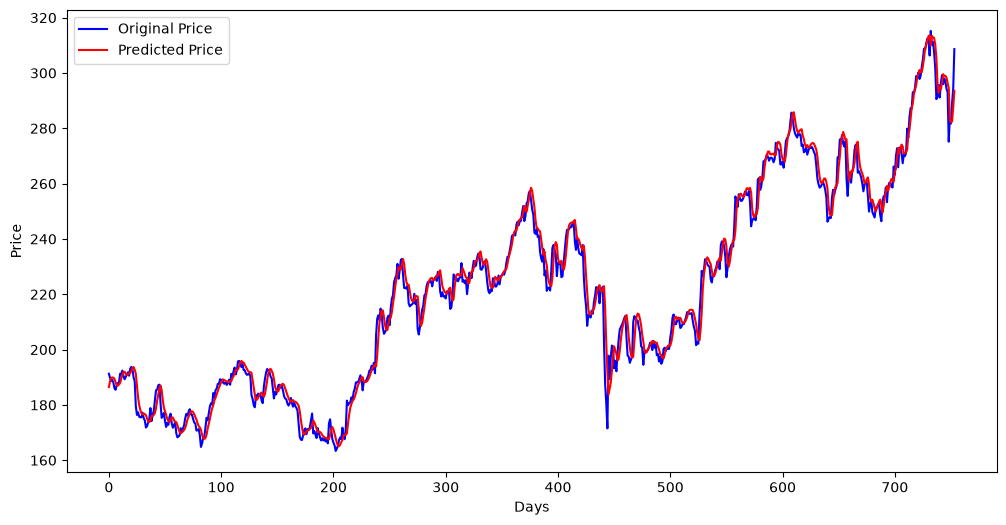

In [82]:
plt.figure(figsize = (12,6))
plt.plot(y_test, 'b', label = "Original Price")
plt.plot(y_predicted, 'r', label = "Predicted Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()

(160.0, 320.0)

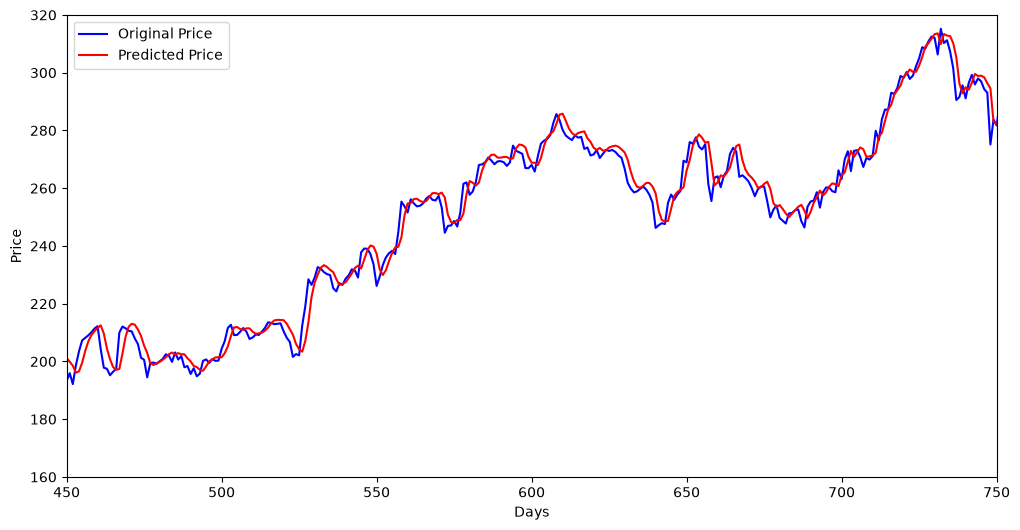

In [92]:
plt.figure(figsize = (12,6))
plt.plot(y_test, 'b', label = "Original Price")
plt.plot(y_predicted, 'r', label = "Predicted Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.xlim(450, 750)
plt.ylim(160, 320)

## 10.Model Evaluation

In [98]:
# Mean Squared Error(MSE)

from sklearn.metrics import mean_squared_error, r2_score

In [95]:
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error (MSE):{mse}")

Mean Squared Error (MSE):20.232213748251805


In [97]:
# Root Mean Squared Erroe (RMSE)

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE):{rmse}")

Root Mean Squared Error (RMSE):4.498023315663427


In [ ]:
# R-Squared

r2 = r2_score(y_test, y_predicted)
print(f"R_")